In [32]:
# =========================================================
# INSTALL REQUIRED PACKAGES (RUN ONCE)
# =========================================================

%pip install -q \
earthengine-api \
geemap \
contextily \
matplotlib-scalebar \
rasterio \
geopandas \
python-dotenv \
xarray \
eemont \
rioxarray \
xee


/Users/adenkumary/Documents/Aden’s MacBook Pro /1.  PhD_ YR_2/6. AAG Abstract/10. Tree_equity_Nairobi/TEI/.venv/bin/python: No module named pip
Note: you may need to restart the kernel to use updated packages.


In [29]:
import ee
import geemap
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import ipywidgets as widgets
from IPython.display import display, clear_output

#%load_ext autoreload
%autoreload 2
import sys
sys.path.append('../src')

from utils.paths import gaul_path
from gee_helpers import authenticate_ee, request_gee_image, get_utm_crs

import geopandas as gpd
import ee
import eemont
import xarray as xr
import rioxarray as rxr
import xee
import geemap
import contextily as ctx



In [19]:
# Authenticate (browser pop-up on first run)
ee.Authenticate()

True

In [20]:
import ee
import geemap

ee.Initialize()

# -----------------------------------
# Load GAUL level 1 (provinces/states)
# -----------------------------------
admin1 = ee.FeatureCollection("FAO/GAUL/2015/level1")

# Filter for Kenya → Nairobi
nairobi = admin1.filter(ee.Filter.And(
    ee.Filter.eq("ADM0_NAME", "Kenya"),
    ee.Filter.eq("ADM1_NAME", "Nairobi")
))

print("Nairobi feature count:", nairobi.size().getInfo())

# Map
Map = geemap.Map()
Map.centerObject(nairobi, 10)
Map.addLayer(nairobi, {"color": "red"}, "Nairobi Boundary")

Map

Nairobi feature count: 1


Map(center=[-1.2899557190767565, 36.86835227030284], controls=(WidgetControl(options=['position', 'transparent…

Total Nairobi districts: 1
['Nairobi']


Output()

Output()

Output()

Output()

Output()

Output()

Output()

Exporting maps for Nairobi: Nairobi
Mean TEI: 49.04


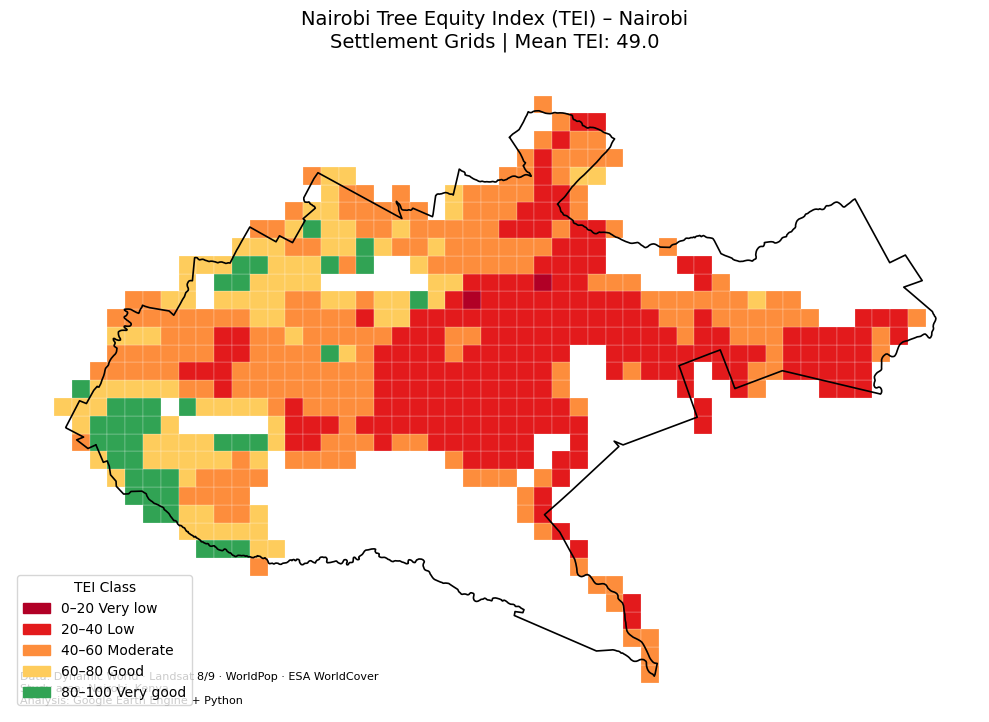

Saved: nairobi_teifinal_Nairobi_plain.png


In [3]:
# =========================================================
# NAIROBI TREE EQUITY INDEX (TEI) WORKFLOW
# Full Jupyter Notebook Code with Subheadings
# =========================================================


# =========================================================
# 1. IMPORTS AND INITIALIZATION
# =========================================================
import ee
import geemap
import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import ipywidgets as widgets

from IPython.display import display, clear_output

ee.Initialize()


# =========================================================
# 2. LOAD NAIROBI DISTRICTS
# =========================================================
districts = ee.FeatureCollection("FAO/GAUL/2015/level2").filter(
    ee.Filter.And(
        ee.Filter.eq("ADM0_NAME", "Kenya"),
        ee.Filter.eq("ADM1_NAME", "Nairobi")
    )
)

NAME_FIELD = "ADM2_NAME"
grid_proj = ee.Projection("EPSG:3857").atScale(1000)   # 1 km grid

district_names = (
    districts.aggregate_array(NAME_FIELD)
    .distinct()
    .sort()
    .getInfo()
)

print(f"Total Nairobi districts: {len(district_names)}")
print(district_names)


# =========================================================
# 3. BASIC DISTRICT MAP FUNCTION
# =========================================================
def draw_district_map(name):
    fc = districts.filter(ee.Filter.eq(NAME_FIELD, name))
    feat = ee.Feature(fc.first())
    grid = feat.geometry().coveringGrid(grid_proj)

    m = geemap.Map()
    m.centerObject(fc, 11)
    m.addLayer(
        districts.style(color="888888", fillColor="00000000", width=1),
        {},
        "Nairobi Districts"
    )
    m.addLayer(
        fc.style(color="yellow", fillColor="FFFF0022", width=3),
        {},
        "Selected District"
    )
    m.addLayer(
        grid.style(color="blue", fillColor="00000000", width=1),
        {},
        "1 km Grid"
    )
    return m


# =========================================================
# 4. SETTLEMENT MASK FUNCTION
# =========================================================
def get_settlement_mask(selected_name):
    """
    Returns:
        hybrid_mask, worldcover_built, ghsl_built, district_fc
    """
    fc = districts.filter(ee.Filter.eq(NAME_FIELD, selected_name))
    geom = fc.geometry()

    # ESA WorldCover built-up = class 50
    wc = (
        ee.ImageCollection("ESA/WorldCover/v200")
        .first()
        .select("Map")
        .clip(geom)
    )
    wc_built = wc.eq(50).rename("wc_built")

    # GHSL built-up, 10m, 2018
    ghsl = (
        ee.Image("JRC/GHSL/P2023A/GHS_BUILT_S_10m/2018")
        .select("built_surface")
        .clip(geom)
    )
    ghsl_built = ghsl.gt(0).rename("ghsl_built")

    # Hybrid settlement mask
    hybrid = wc_built.Or(ghsl_built).rename("settlement")

    return hybrid, wc_built, ghsl_built, fc


# =========================================================
# 5. SETTLEMENT GRID CALCULATION
# =========================================================
def calc_settlement_grid(selected_name, min_settlement_pct=20):
    """
    Returns:
        district_fc, settlement_mask, all_grid_stats, settlement_grid
    """
    fc = districts.filter(ee.Filter.eq(NAME_FIELD, selected_name))
    geom = ee.Feature(fc.first()).geometry()

    mask, _, _, _ = get_settlement_mask(selected_name)

    grid = geom.coveringGrid(grid_proj).filterBounds(geom)

    stats = mask.reduceRegions(
        collection=grid,
        reducer=ee.Reducer.mean(),
        scale=10
    )

    def add_pct(f):
        v = ee.Algorithms.If(
            ee.Algorithms.IsEqual(f.get("mean"), None),
            0,
            f.get("mean")
        )
        return ee.Feature(f).set({
            "settlement_mean": v,
            "settlement_pct": ee.Number(v).multiply(100)
        })

    stats = stats.map(add_pct)
    s_grid = stats.filter(ee.Filter.gte("settlement_pct", min_settlement_pct))

    return fc, mask, stats, s_grid


# =========================================================
# 6. STYLE FUNCTION FOR GRID CLASSES
# =========================================================
def _style_by_breaks(fc, field, breaks, colors):
    """Generic graduated colour styling."""
    def add_style(f):
        val = ee.Number(f.get(field))
        color = colors[-1]

        for thr, col in reversed(list(zip(breaks, colors[:-1]))):
            color = ee.Algorithms.If(val.lt(thr), col, color)

        return ee.Feature(f).set("style", {
            "fillColor": color,
            "color": "00000055",
            "width": 0.5
        })

    return fc.map(add_style)


# =========================================================
# 7. CANOPY PER SETTLEMENT GRID
# =========================================================
def calc_canopy_settlement(selected_name, min_settlement_pct=20):
    """
    Returns:
        district_fc, settlement_grid, canopy_grid_stats
    """
    fc, _, _, s_grid = calc_settlement_grid(selected_name, min_settlement_pct)
    geom = fc.geometry()

    dw = (
        ee.ImageCollection("GOOGLE/DYNAMICWORLD/V1")
        .filterBounds(geom)
        .filterDate("2023-01-01", "2023-12-31")
    )

    tree_cover = (
        dw.select("label")
        .map(lambda img: img.eq(1).rename("trees"))
        .mean()
        .clip(geom)
    )

    stats = tree_cover.reduceRegions(
        collection=s_grid,
        reducer=ee.Reducer.mean(),
        scale=10
    )

    def add_tree_pct(f):
        v = ee.Algorithms.If(
            ee.Algorithms.IsEqual(f.get("mean"), None),
            0,
            f.get("mean")
        )
        return ee.Feature(f).set({
            "tree_mean": v,
            "tree_pct": ee.Number(v).multiply(100)
        })

    return fc, s_grid, stats.map(add_tree_pct)


# =========================================================
# 8. LAND SURFACE TEMPERATURE (LST) PER SETTLEMENT GRID
# =========================================================
def mask_landsat_l2(image):
    """Remove clouds and cloud shadows using QA_PIXEL band."""
    qa = image.select("QA_PIXEL")
    cloud = qa.bitwiseAnd(1 << 3).neq(0)
    shadow = qa.bitwiseAnd(1 << 4).neq(0)
    return image.updateMask(cloud.Or(shadow).Not())


def calc_lst_settlement(selected_name, min_settlement_pct=20):
    """
    Returns:
        district_fc, settlement_grid, lst_grid_stats
    """
    fc, _, _, s_grid = calc_settlement_grid(selected_name, min_settlement_pct)
    geom = fc.geometry()

    def load_ls(collection_id):
        return (
            ee.ImageCollection(collection_id)
            .filterBounds(geom)
            .filterDate("2023-01-01", "2023-12-31")
            .map(mask_landsat_l2)
        )

    landsat = load_ls("LANDSAT/LC08/C02/T1_L2").merge(
        load_ls("LANDSAT/LC09/C02/T1_L2")
    )

    lst_img = (
        landsat.select("ST_B10")
        .map(lambda img: img.multiply(0.00341802).add(149.0).subtract(273.15).rename("LST"))
        .median()
        .clip(geom)
    )

    stats = lst_img.reduceRegions(
        collection=s_grid,
        reducer=ee.Reducer.mean(),
        scale=30
    )

    def add_lst(f):
        v = ee.Algorithms.If(
            ee.Algorithms.IsEqual(f.get("mean"), None),
            -9999,
            f.get("mean")
        )
        return ee.Feature(f).set({"lst_mean_c": v})

    return fc, s_grid, stats.map(add_lst).filter(ee.Filter.neq("lst_mean_c", -9999))


# =========================================================
# 9. POPULATION PER SETTLEMENT GRID
# =========================================================
def calc_population_settlement(selected_name, min_settlement_pct=20):
    """
    Returns:
        district_fc, settlement_grid, pop_grid_stats
    """
    fc, _, _, s_grid = calc_settlement_grid(selected_name, min_settlement_pct)
    geom = fc.geometry()

    pop = (
        ee.ImageCollection("WorldPop/GP/100m/pop")
        .filterBounds(geom)
        .filter(ee.Filter.eq("year", 2020))
        .mosaic()
        .rename("population")
        .clip(geom)
    )

    stats = pop.reduceRegions(
        collection=s_grid,
        reducer=ee.Reducer.sum(),
        scale=100
    )

    def add_pop(f):
        v = ee.Algorithms.If(
            ee.Algorithms.IsEqual(f.get("sum"), None),
            0,
            f.get("sum")
        )
        return ee.Feature(f).set({"population": v})

    return fc, s_grid, stats.map(add_pop)


# =========================================================
# 10. BUILT-UP PER SETTLEMENT GRID
# =========================================================
def calc_built_settlement(selected_name, min_settlement_pct=20):
    """
    Returns:
        district_fc, settlement_grid, built_grid_stats
    """
    fc, _, _, s_grid = calc_settlement_grid(selected_name, min_settlement_pct)
    geom = fc.geometry()

    built = (
        ee.ImageCollection("ESA/WorldCover/v200")
        .first()
        .select("Map")
        .eq(50)
        .rename("built")
        .clip(geom)
    )

    stats = built.reduceRegions(
        collection=s_grid,
        reducer=ee.Reducer.mean(),
        scale=10
    )

    def add_built_pct(f):
        v = ee.Algorithms.If(
            ee.Algorithms.IsEqual(f.get("mean"), None),
            0,
            f.get("mean")
        )
        return ee.Feature(f).set({
            "built_mean": v,
            "built_pct": ee.Number(v).multiply(100)
        })

    return fc, s_grid, stats.map(add_built_pct)


# =========================================================
# 11. HELPERS FOR JOINING AND NORMALISING GRID DATA
# =========================================================
def add_grid_id(fc):
    fc_list = fc.toList(fc.size())

    def set_id(i):
        f = ee.Feature(fc_list.get(i))
        return f.set("grid_id", ee.Number(i).format("%d"))

    return ee.FeatureCollection(
        ee.List.sequence(0, fc.size().subtract(1)).map(set_id)
    )


def join_fc(left_fc, right_fc, right_fields):
    """Inner-join two FCs on grid_id and copy right_fields onto left."""
    joined = ee.Join.inner().apply(
        left_fc,
        right_fc,
        ee.Filter.equals(leftField="grid_id", rightField="grid_id")
    )

    def merge(f):
        left = ee.Feature(f.get("primary"))
        right = ee.Feature(f.get("secondary"))
        return left.set({field: right.get(field) for field in right_fields})

    return ee.FeatureCollection(joined.map(merge))


def normalize(fc, field, new_field):
    """Min-max normalise a field to [0, 1]."""
    min_v = ee.Number(fc.aggregate_min(field))
    max_v = ee.Number(fc.aggregate_max(field))

    def add_norm(f):
        val = ee.Number(f.get(field))
        norm = ee.Algorithms.If(
            max_v.eq(min_v),
            0,
            val.subtract(min_v).divide(max_v.subtract(min_v))
        )
        return ee.Feature(f).set(new_field, norm)

    return fc.map(add_norm)


# =========================================================
# 12. BUILD FINAL TREE EQUITY INDEX (TEI)
# =========================================================
def build_tei_fc(selected_name, min_settlement_pct=20):
    """
    Assemble all layers, normalise, and compute TEI score.
    """
    _, _, canopy = calc_canopy_settlement(selected_name, min_settlement_pct)
    _, _, lst    = calc_lst_settlement(selected_name, min_settlement_pct)
    _, _, pop    = calc_population_settlement(selected_name, min_settlement_pct)
    _, _, built  = calc_built_settlement(selected_name, min_settlement_pct)

    canopy = add_grid_id(canopy)
    lst    = add_grid_id(lst)
    pop    = add_grid_id(pop)
    built  = add_grid_id(built)

    merged = join_fc(canopy, lst,   ["lst_mean_c"])
    merged = join_fc(merged, pop,   ["population"])
    merged = join_fc(merged, built, ["built_pct"])

    merged = normalize(merged, "tree_pct",   "tree_norm")
    merged = normalize(merged, "lst_mean_c", "heat_norm")
    merged = normalize(merged, "population", "pop_norm")
    merged = normalize(merged, "built_pct",  "built_norm")

    def add_score(f):
        tree_n  = ee.Number(f.get("tree_norm"))
        heat_n  = ee.Number(f.get("heat_norm"))
        pop_n   = ee.Number(f.get("pop_norm"))
        built_n = ee.Number(f.get("built_norm"))

        veg_def = ee.Number(1).subtract(tree_n)

        priority = (
            heat_n.multiply(0.35)
            .add(veg_def.multiply(0.30))
            .add(pop_n.multiply(0.20))
            .add(built_n.multiply(0.15))
        )

        tei = ee.Number(100).multiply(ee.Number(1).subtract(priority))

        return ee.Feature(f).set({
            "veg_deficit": veg_def,
            "priority": priority,
            "tei_score": tei
        })

    return merged.map(add_score)


# =========================================================
# 13. TEI CLASSIFICATION AND MAP LEGEND HELPERS
# =========================================================
COLOR_MAP = {
    "0–20 Very low":    "#b10026",
    "20–40 Low":        "#e31a1c",
    "40–60 Moderate":   "#fd8d3c",
    "60–80 Good":       "#fecc5c",
    "80–100 Very good": "#31a354",
}

CLASS_ORDER = list(COLOR_MAP.keys())


def classify_tei(x):
    if x < 20:
        return "0–20 Very low"
    elif x < 40:
        return "20–40 Low"
    elif x < 60:
        return "40–60 Moderate"
    elif x < 80:
        return "60–80 Good"
    else:
        return "80–100 Very good"


def legend_handles():
    return [mpatches.Patch(color=COLOR_MAP[k], label=k) for k in CLASS_ORDER]


def add_legend_and_title(ax, name, mean_tei):
    ax.set_title(
        f"Nairobi Tree Equity Index (TEI) – {name}\n"
        f"Settlement Grids | Mean TEI: {mean_tei:.1f}",
        fontsize=14,
        pad=14
    )
    ax.legend(
        handles=legend_handles(),
        title="TEI Class",
        loc="lower left",
        frameon=True
    )
    ax.text(
        0.01, 0.01,
        "Data: Dynamic World · Landsat 8/9 · WorldPop · ESA WorldCover\n"
        "Study area: Nairobi, Kenya\n"
        "Analysis: Google Earth Engine + Python",
        transform=ax.transAxes,
        fontsize=8,
        va="bottom"
    )
    ax.set_axis_off()


# =========================================================
# 14. INTERACTIVE WIDGETS
# =========================================================
district_dd = widgets.Dropdown(
    options=district_names,
    description="District:",
    layout=widgets.Layout(width="400px")
)

run_btn = widgets.Button(description="Load District", button_style="success")
btn_settlement = widgets.Button(description="Generate Settlement Mask", button_style="info")
btn_s_grid = widgets.Button(description="Generate Settlement Grids", button_style="warning")
btn_canopy = widgets.Button(description="Canopy per Settlement Grid", button_style="success")
btn_built = widgets.Button(description="Built-up per Settlement Grid", button_style="warning")
btn_tei = widgets.Button(description="Run Final TEI Model", button_style="success")

out = widgets.Output()
settlement_out = widgets.Output()
s_grid_out = widgets.Output()
canopy_out = widgets.Output()
built_out = widgets.Output()
tei_out = widgets.Output()
map_out = widgets.Output()

display(
    widgets.HBox([district_dd, run_btn, btn_settlement, btn_s_grid, btn_canopy, btn_built, btn_tei]),
    out,
    settlement_out,
    s_grid_out,
    canopy_out,
    built_out,
    tei_out,
    map_out
)


# =========================================================
# 15. BUTTON ACTIONS
# =========================================================
def on_run_clicked(b):
    with out:
        out.clear_output()
        print("Selected district:", district_dd.value)

    with map_out:
        clear_output(wait=True)
        display(draw_district_map(district_dd.value))

    with out:
        print("✅ Done.")


def on_settlement_clicked(b):
    with settlement_out:
        settlement_out.clear_output()
        print("Generating settlement mask …")

    mask, wc_built, ghsl_built, fc = get_settlement_mask(district_dd.value)

    with map_out:
        clear_output(wait=True)
        m = geemap.Map()
        m.centerObject(fc, 11)
        m.addLayer(wc_built.selfMask(), {"palette": ["red"]}, "WorldCover Built-up")
        m.addLayer(ghsl_built.selfMask(), {"palette": ["orange"]}, "GHSL Built-up")
        m.addLayer(mask.selfMask(), {"palette": ["blue"]}, "Hybrid Settlement Mask")
        m.addLayer(fc.style(color="black", fillColor="00000000", width=2), {}, "District")
        display(m)

    with settlement_out:
        print("✅ Done. Red=WorldCover | Orange=GHSL | Blue=Hybrid")


def on_s_grid_clicked(b):
    with s_grid_out:
        s_grid_out.clear_output()
        print("Generating settlement grids …")

    name = district_dd.value
    fc, mask, all_stats, s_grid = calc_settlement_grid(name)

    styled = _style_by_breaks(
        s_grid, "settlement_pct",
        [20, 40, 60, 80],
        ["#ffffcc", "#c2e699", "#78c679", "#31a354", "#006837"]
    )

    with map_out:
        clear_output(wait=True)
        m = geemap.Map()
        m.centerObject(fc, 11)
        m.addLayer(mask.selfMask(), {"palette": ["blue"]}, "Settlement Mask")
        m.addLayer(styled.style(styleProperty="style"), {}, "Settlement Grids")
        m.addLayer(fc.style(color="black", fillColor="00000000", width=2), {}, "Selected Nairobi District")
        display(m)

    total = all_stats.size().getInfo()
    kept = s_grid.size().getInfo()
    mean_val = s_grid.aggregate_mean("settlement_pct").getInfo()
    mean = 0 if mean_val is None else mean_val

    with s_grid_out:
        print(f"✅ {name} | Total grids: {total} | Settlement grids: {kept} | Mean settlement %: {mean:.2f}")


def on_canopy_clicked(b):
    with canopy_out:
        canopy_out.clear_output()
        print("Calculating canopy cover …")

    name = district_dd.value
    fc, _, grid = calc_canopy_settlement(name)

    styled = _style_by_breaks(
        grid, "tree_pct",
        [5, 10, 20, 30, 40, 50, 60],
        ["#f7fcf5", "#e5f5e0", "#c7e9c0", "#a1d99b",
         "#74c476", "#41ab5d", "#238b45", "#005a32"]
    )

    with map_out:
        clear_output(wait=True)
        m = geemap.Map()
        m.centerObject(fc, 11)
        m.addLayer(styled.style(styleProperty="style"), {}, "Tree Canopy (Settlement)")
        m.addLayer(fc.style(color="black", fillColor="00000000", width=2), {}, "Selected Nairobi District")
        display(m)

    mean_val = grid.aggregate_mean("tree_pct").getInfo()
    min_val = grid.aggregate_min("tree_pct").getInfo()
    max_val = grid.aggregate_max("tree_pct").getInfo()

    mean = 0 if mean_val is None else mean_val
    mn = 0 if min_val is None else min_val
    mx = 0 if max_val is None else max_val

    with canopy_out:
        print(f"✅ {name} | Mean: {mean:.2f}% | Min: {mn:.2f}% | Max: {mx:.2f}%")


def on_built_clicked(b):
    with built_out:
        built_out.clear_output()
        print("Calculating built-up fraction …")

    name = district_dd.value
    fc, _, grid = calc_built_settlement(name)

    styled = _style_by_breaks(
        grid, "built_pct",
        [1, 5, 10, 20],
        ["#ffffcc", "#ffeda0", "#feb24c", "#f03b20", "#bd0026"]
    )

    with map_out:
        clear_output(wait=True)
        m = geemap.Map()
        m.centerObject(fc, 11)
        m.addLayer(styled.style(styleProperty="style"), {}, "Built-up (Settlement)")
        m.addLayer(fc.style(color="black", fillColor="00000000", width=2), {}, "Selected Nairobi District")
        display(m)

    mean_val = grid.aggregate_mean("built_pct").getInfo()
    min_val = grid.aggregate_min("built_pct").getInfo()
    max_val = grid.aggregate_max("built_pct").getInfo()

    mean = 0 if mean_val is None else mean_val
    mn = 0 if min_val is None else min_val
    mx = 0 if max_val is None else max_val

    with built_out:
        print(f"✅ {name} | Mean: {mean:.2f}% | Min: {mn:.2f}% | Max: {mx:.2f}%")


def on_tei_clicked(b):
    with tei_out:
        tei_out.clear_output()
        print("Computing TEI – this may take a minute …")

    name = district_dd.value
    fc = districts.filter(ee.Filter.eq(NAME_FIELD, name))
    tei_fc = build_tei_fc(name)

    styled = _style_by_breaks(
        tei_fc, "tei_score",
        [20, 40, 60, 80],
        ["#b10026", "#e31a1c", "#fd8d3c", "#fecc5c", "#31a354"]
    )

    with map_out:
        clear_output(wait=True)
        m = geemap.Map()
        m.centerObject(fc, 11)
        m.addLayer(styled.style(styleProperty="style"), {}, "Tree Equity Index")
        m.addLayer(fc.style(color="black", fillColor="00000000", width=2), {}, "Selected Nairobi District")
        display(m)

    mean_val = tei_fc.aggregate_mean("tei_score").getInfo()
    min_val = tei_fc.aggregate_min("tei_score").getInfo()
    max_val = tei_fc.aggregate_max("tei_score").getInfo()

    mean = 0 if mean_val is None else mean_val
    mn = 0 if min_val is None else min_val
    mx = 0 if max_val is None else max_val

    with tei_out:
        print(f"✅ {name}")
        print(f"   Mean TEI : {mean:.2f}")
        print(f"   Min  TEI : {mn:.2f}")
        print(f"   Max  TEI : {mx:.2f}")
        print()
        print("TEI Classes: 0–20 Very low | 20–40 Low | 40–60 Moderate | 60–80 Good | 80–100 Very good")


run_btn.on_click(on_run_clicked)
btn_settlement.on_click(on_settlement_clicked)
btn_s_grid.on_click(on_s_grid_clicked)
btn_canopy.on_click(on_canopy_clicked)
btn_built.on_click(on_built_clicked)
btn_tei.on_click(on_tei_clicked)


# =========================================================
# 16. INITIAL OVERVIEW MAP
# =========================================================
with map_out:
    m0 = geemap.Map()
    m0.centerObject(districts, 10)
    m0.addLayer(
        districts.style(color="888888", fillColor="00000000", width=1),
        {},
        "Nairobi Districts"
    )
    display(m0)


# =========================================================
# 17. EXPORT TEI RESULTS TO GEODATAFRAME
# Run this after clicking "Run Final TEI Model"
# =========================================================
SELECTED_NAME = district_dd.value
print("Exporting maps for Nairobi:", SELECTED_NAME)

tei_fc = build_tei_fc(SELECTED_NAME)
district_fc = districts.filter(ee.Filter.eq(NAME_FIELD, SELECTED_NAME))

tei_gdf = geemap.ee_to_gdf(tei_fc)
district_gdf = geemap.ee_to_gdf(district_fc)

tei_gdf["tei_class"] = tei_gdf["tei_score"].apply(classify_tei)
tei_gdf["color"] = tei_gdf["tei_class"].map(COLOR_MAP)

if len(tei_gdf) == 0:
    print("⚠️ No TEI results for this district.")
else:
    mean_tei = tei_gdf["tei_score"].mean()
    print(f"Mean TEI: {mean_tei:.2f}")


# =========================================================
# 18. MAP 1: PLAIN CHOROPLETH EXPORT
# =========================================================
if len(tei_gdf) > 0:
    fig, ax = plt.subplots(figsize=(10, 10))

    tei_gdf.plot(
        ax=ax,
        color=tei_gdf["color"],
        edgecolor="white",
        linewidth=0.15
    )

    district_gdf.boundary.plot(
        ax=ax,
        color="black",
        linewidth=1.2
    )

    add_legend_and_title(ax, SELECTED_NAME, mean_tei)
    plt.tight_layout()

    safe_name = SELECTED_NAME.replace(" ", "_").replace("/", "_")
    out_plain = f"nairobi_teifinal_{safe_name}_plain.png"

    plt.savefig(out_plain, dpi=300, bbox_inches="tight")
    plt.show()
    print("Saved:", out_plain)

In [4]:
# ── Run this cell after the TEI model has finished ──────────────────────────
SELECTED_NAME = district_dd.value
print("Exporting maps for:", SELECTED_NAME)

tei_fc      = build_tei_fc(SELECTED_NAME)
district_fc = districts.filter(ee.Filter.eq(NAME_FIELD, SELECTED_NAME))

tei_gdf      = geemap.ee_to_gdf(tei_fc)
district_gdf = geemap.ee_to_gdf(district_fc)

tei_gdf["tei_class"] = tei_gdf["tei_score"].apply(classify_tei)
tei_gdf["color"]     = tei_gdf["tei_class"].map(COLOR_MAP)

mean_tei = tei_gdf["tei_score"].mean()
print(f"Mean TEI: {mean_tei:.2f}")

Exporting maps for: Nairobi
Mean TEI: 49.04


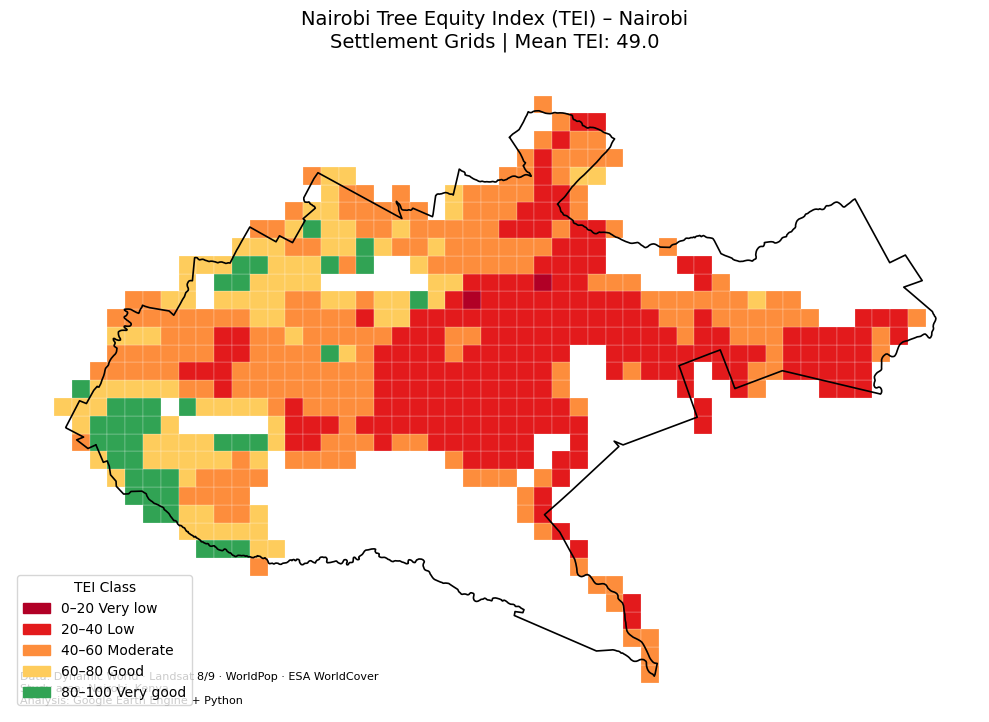

Saved: tei_Nairobi_plain.png


In [5]:
# ── Map 1: Plain choropleth ─────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 10))
tei_gdf.plot(ax=ax, color=tei_gdf["color"], edgecolor="white", linewidth=0.15)
district_gdf.boundary.plot(ax=ax, color="black", linewidth=1.2)
add_legend_and_title(ax, SELECTED_NAME, mean_tei)
plt.tight_layout()

out_plain = f"tei_{SELECTED_NAME}_plain.png"
plt.savefig(out_plain, dpi=300, bbox_inches="tight")
plt.show()
print("Saved:", out_plain)

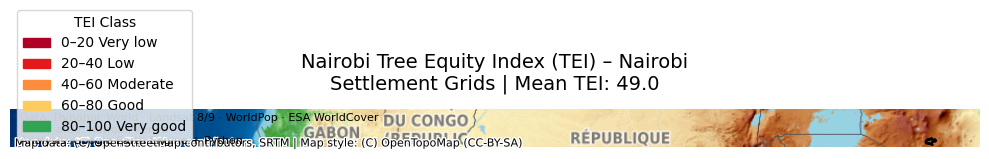

Saved: tei_Nairobi_terrain.png


In [7]:
# ── Map 2: Terrain basemap (OpenTopoMap) ────────────────────────────────────
tei_web      = tei_gdf.to_crs(epsg=3857)
district_web = district_gdf.to_crs(epsg=3857)

fig, ax = plt.subplots(figsize=(10, 10))
tei_web.plot(ax=ax, color=tei_web["color"], edgecolor="white", linewidth=0.2, alpha=0.85)
district_web.boundary.plot(ax=ax, color="black", linewidth=1.5)
ctx.add_basemap(ax, source=ctx.providers.OpenTopoMap)
add_legend_and_title(ax, SELECTED_NAME, mean_tei)
plt.tight_layout()

out_terrain = f"tei_{SELECTED_NAME}_terrain.png"
plt.savefig(out_terrain, dpi=300, bbox_inches="tight")
plt.show()
print("Saved:", out_terrain)

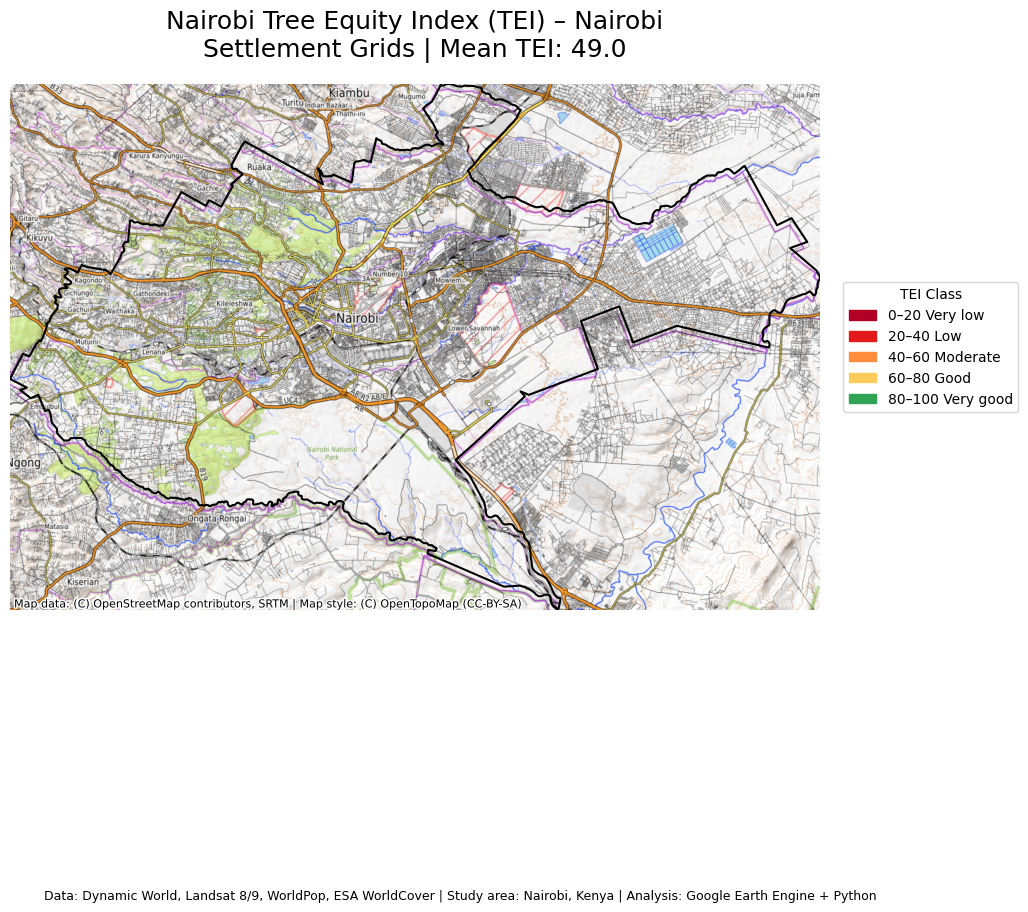

Saved: tei_Nairobi_terrain.png


In [8]:
# Reproject to Web Mercator for basemap
tei_web = tei_gdf.to_crs(epsg=3857)
district_web = district_gdf.to_crs(epsg=3857)

fig, ax = plt.subplots(figsize=(12, 12))

tei_web.plot(
    ax=ax,
    color=tei_web["color"],
    edgecolor="white",
    linewidth=0.2,
    alpha=0.85
)

district_web.boundary.plot(
    ax=ax,
    color="black",
    linewidth=1.5
)

# Keep map extent tight around Nairobi
xmin, ymin, xmax, ymax = district_web.total_bounds
ax.set_xlim(xmin, xmax)
ax.set_ylim(ymin, ymax)
ax.set_aspect("equal")

ctx.add_basemap(
    ax,
    source=ctx.providers.OpenTopoMap,
    zoom=12
)

# Title
ax.set_title(
    f"Nairobi Tree Equity Index (TEI) – {SELECTED_NAME}\n"
    f"Settlement Grids | Mean TEI: {mean_tei:.1f}",
    fontsize=18,
    pad=20
)

# Legend outside the map
legend_handles = [
    mpatches.Patch(color=COLOR_MAP[k], label=k)
    for k in [
        "0–20 Very low",
        "20–40 Low",
        "40–60 Moderate",
        "60–80 Good",
        "80–100 Very good"
    ]
]

ax.legend(
    handles=legend_handles,
    title="TEI Class",
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    frameon=True
)

# Credits outside map area
fig.text(
    0.5, 0.02,
    "Data: Dynamic World, Landsat 8/9, WorldPop, ESA WorldCover | "
    "Study area: Nairobi, Kenya | Analysis: Google Earth Engine + Python",
    ha="center",
    fontsize=9
)

ax.set_axis_off()

plt.subplots_adjust(right=0.8, top=0.88, bottom=0.08)

out_terrain = f"tei_{SELECTED_NAME}_terrain.png"
plt.savefig(out_terrain, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", out_terrain)